# **Multiple Linear Regression (MLR)**

**importing pandas,numpy,matplotlib**

In [5]:
import pandas as pd
import numpy as np
import matplotlib as mpl
from matplotlib import pyplot as plt

**Topic covered till now**
- y = beta_0 + beta_1x
- dependent and independent variables
- eg: On sales (dependent), [radio, tv, newspaper] (independent) {independent may be one to many}


**Today**

- performing multiple linear regression
  - sales vs [tv,radio,newspaper]
  - Formula: y = beta_0 + beta_1_x1 + beta_2_x2 + beta_3_x3

In [3]:
data_df = pd.read_csv("https://www.statlearning.com/s/Advertising.csv",index_col= 0)

In [4]:
data_df.sample(5)

,TV,radio,newspaper,sales
44,206.9,8.4,26.4,12.9
95,107.4,14.0,10.9,11.5
200,232.1,8.6,8.7,13.4
144,104.6,5.7,34.4,10.4
14,97.5,7.6,7.2,9.7


**Creating plot of each**

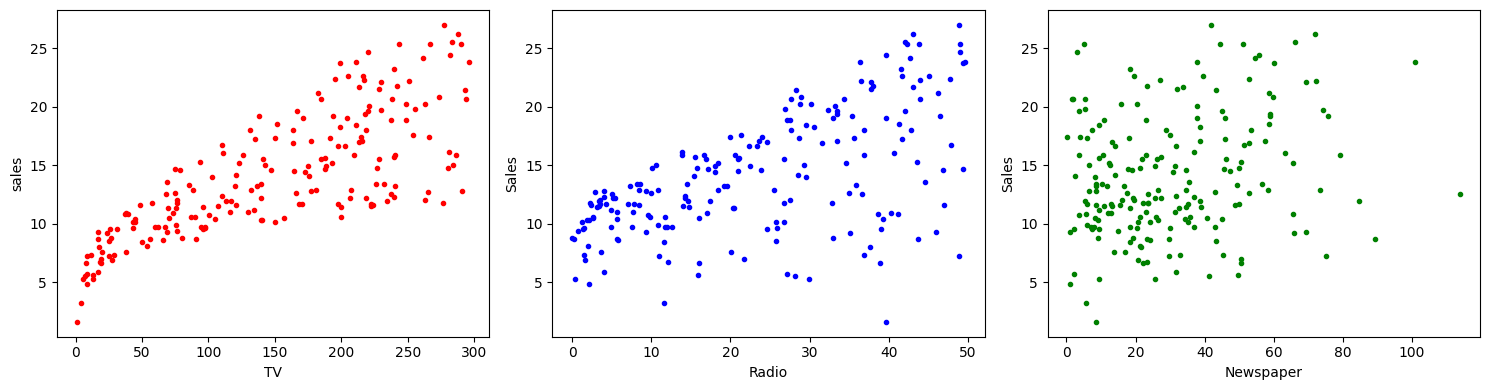

In [7]:
fig = plt.figure(figsize=(15,4))
gs = mpl.gridspec.GridSpec(1,3) # grid size (row * column)

ax = fig.add_subplot(gs[0])
ax.scatter(data_df["TV"],data_df["sales"],color = "red",marker = ".")
ax.set_xlabel("TV")
ax.set_ylabel("sales")

ax2 = fig.add_subplot(gs[0, 1])
ax2.scatter(data_df["radio"], data_df["sales"], color="blue", marker=".")
ax2.set_xlabel("Radio")
ax2.set_ylabel("Sales")

ax3 = fig.add_subplot(gs[0, 2])
ax3.scatter(data_df["newspaper"], data_df["sales"], color="green", marker=".")
ax3.set_xlabel("Newspaper")
ax3.set_ylabel("Sales")

plt.tight_layout()
plt.show()

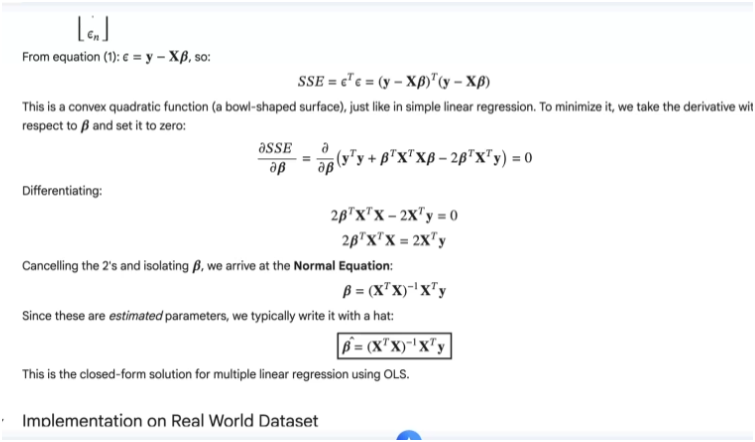

In [9]:
from IPython.display import display,Math
x = data_df[["TV","radio","newspaper"]]
y = data_df[["sales"]]

**set bias term 1 for each 200 rows samples**

In [12]:
X = np.c_[np.ones((200,1)),x]
X[:4]

array([[  1. , 230.1,  37.8,  69.2],
       [  1. ,  44.5,  39.3,  45.1],
       [  1. ,  17.2,  45.9,  69.3],
       [  1. , 151.5,  41.3,  58.5]])

In [15]:
X_transpose = np.transpose(X)
X_transpose[:,:4]

array([[  1. ,   1. ,   1. ,   1. ],
       [230.1,  44.5,  17.2, 151.5],
       [ 37.8,  39.3,  45.9,  41.3],
       [ 69.2,  45.1,  69.3,  58.5]])

In [16]:
X_transpose.shape

(4, 200)

**finding ordinary least squares**

In [17]:
beta = np.linalg.inv(X_transpose.dot(X)).dot(X_transpose).dot(y)

In [19]:
beta

array([[ 2.93888937e+00],
       [ 4.57646455e-02],
       [ 1.88530017e-01],
       [-1.03749304e-03]])

In [41]:
display(Math(r"\mathbf{TV,\ Radio, \ and \ NewsPaper}"))
display(Math(
    rf"y = {beta[0,0]:.2f} {beta[1,0]:+.2f}x_1 {beta[2,0]:+.2f}x_2 {beta[3,0]:+.2f}x_3"
))
display(Math(r"x_1 = \mathrm{TV}"))
display(Math(r"x_2 = \mathrm{Radio}"))
display(Math(r"x_3 = \mathrm{NewsPaper}"))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

# **Finding performance metrics**

In [57]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
le = LinearRegression()

In [58]:
x = data_df[["TV","radio","newspaper"]].to_numpy()
y = data_df[["sales"]].to_numpy()

In [59]:
scaler_x = scaler.fit_transform(x)


In [60]:
X_train,X_test,y_train,y_test = train_test_split(x,y,test_size = 0.2,random_state = 42)

In [61]:
le.fit(X_train,y_train)

LinearRegression()

In [62]:
y_pred = le.predict(X_test)

**Performance Metrics**

In [63]:
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score

In [64]:
mse = mean_squared_error(y_test,y_pred)
mse

3.174097353976104

In [65]:
mae = mean_absolute_error(y_test,y_pred)
mae

1.4607567168117601

In [66]:
r2 = r2_score(y_test,y_pred)
r2

0.899438024100912

**Possible error in this model**
- if there are multiple variable and their correlation is high
  - 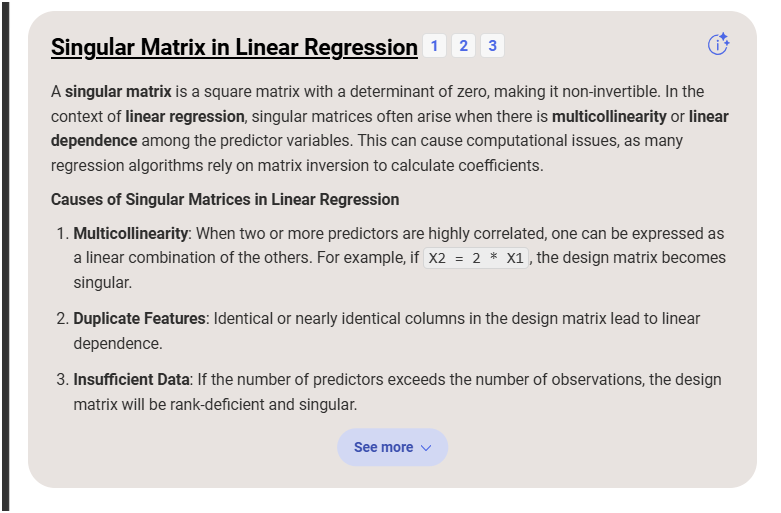
- not existance of (X_transpose * X) ^ -1
- insufficient number of observations

**Possible solutions**
- 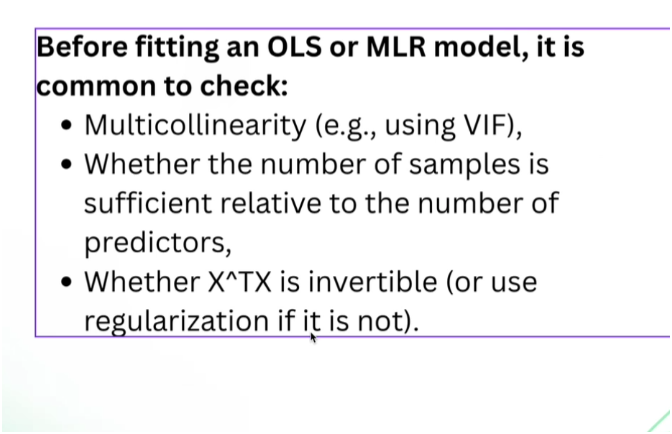